# **전복 성별 예측 다중분류 - 머신러닝(랜덤포레스트), 딥러닝(Dense)**
- 라벨 : 수컷(M), 암컷(F), 유체(I, 미성숙 전복)

In [30]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

# 데이터 불러오기

In [31]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/6week/abalone.csv")
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10




---



# 0. 전체 데이터셋 구조

In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              4177 non-null   int64  
 1   Sex             4177 non-null   object 
 2   Length          4177 non-null   float64
 3   Diameter        4177 non-null   float64
 4   Height          4177 non-null   float64
 5   Whole_weight    4177 non-null   float64
 6   Shucked_weight  4177 non-null   float64
 7   Viscera_weight  4177 non-null   float64
 8   Shell_weight    4177 non-null   float64
 9   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 326.5+ KB
None


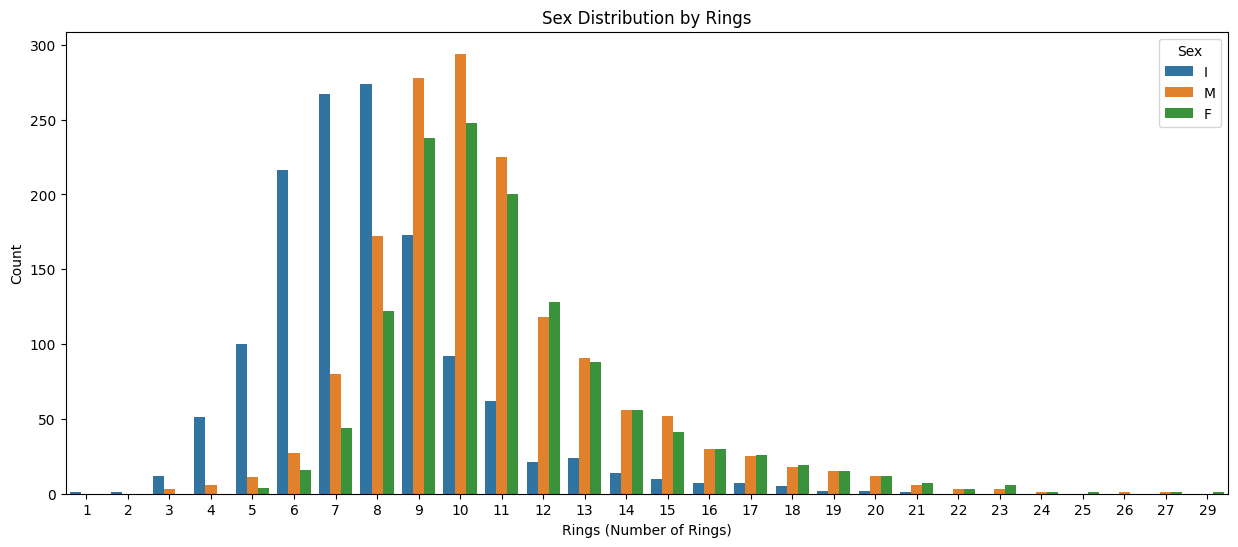

In [33]:
# 링 개수별 성별 분포
plt.figure(figsize=(15, 6))

sns.countplot(data=df, x="Rings", hue="Sex")

plt.xlabel("Rings (Number of Rings)")
plt.ylabel("Count")
plt.title("Sex Distribution by Rings")
plt.legend(title="Sex")
plt.show()

In [58]:
# 정답(Sex) label별 갯수
df['Sex'].value_counts()

,count
Sex,
M,1528
I,1342
F,1307




---



# 1. 데이터 전처리

In [46]:
# 1-1. Test/Train 데이터 분할

# df 데이터를 8:2로 나누기
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# df_train, df_test 크기 확인
print("Training data size:", df_train.shape)
print("Test data size:", df_test.shape)

Training data size: (3341, 11)
Test data size: (836, 11)


In [47]:
df_train.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Real weight
4038,4038,I,0.550,0.445,0.125,0.6720,0.2880,0.1365,0.210,11,0.428571
1272,1272,I,0.475,0.355,0.100,0.5035,0.2535,0.0910,0.140,8,0.503476
3384,3384,F,0.305,0.225,0.070,0.1485,0.0585,0.0335,0.045,7,0.393939
3160,3160,I,0.275,0.200,0.065,0.1165,0.0565,0.0130,0.035,7,0.484979
3894,3894,M,0.495,0.380,0.135,0.6295,0.2630,0.1425,0.215,12,0.417792


In [61]:
# 1-2. Feature Engineering

# Real weight = 껍질 제거 후 무게 / 전체 무게
# 실제로 살이 얼마나 들었는지
# 같은 Whole_weight 라도 Shucked_weight 값에 따라 살이 많고 적음이 달라짐

df_train["Real weight"] = df_train["Shucked_weight"] / df_train["Whole_weight"]
df_test["Real weight"] = df_test["Shucked_weight"] / df_test["Whole_weight"]

df_train.columns

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
       'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings',
       'Real weight', 'typ'],
      dtype='object')

# + 히트맵 : 상관관계 분석
- 정답(Rings)과 관계 : 크기/무게 관련 변수들이 정답(나이)에 영향이 큼
  - Shell_weight = 0.63 (가장 큼)
  - Diameter = 0.57
  - Length, Height = 0.55
  - Real weight = -0.34 (음의상관)

In [49]:
cat_cols=['Sex']
num_cols=['Length', 'Diameter', 'Height',
             'Whole_weight','Shucked_weight',
             'Viscera_weight', 'Shell_weight', "Real weight"]

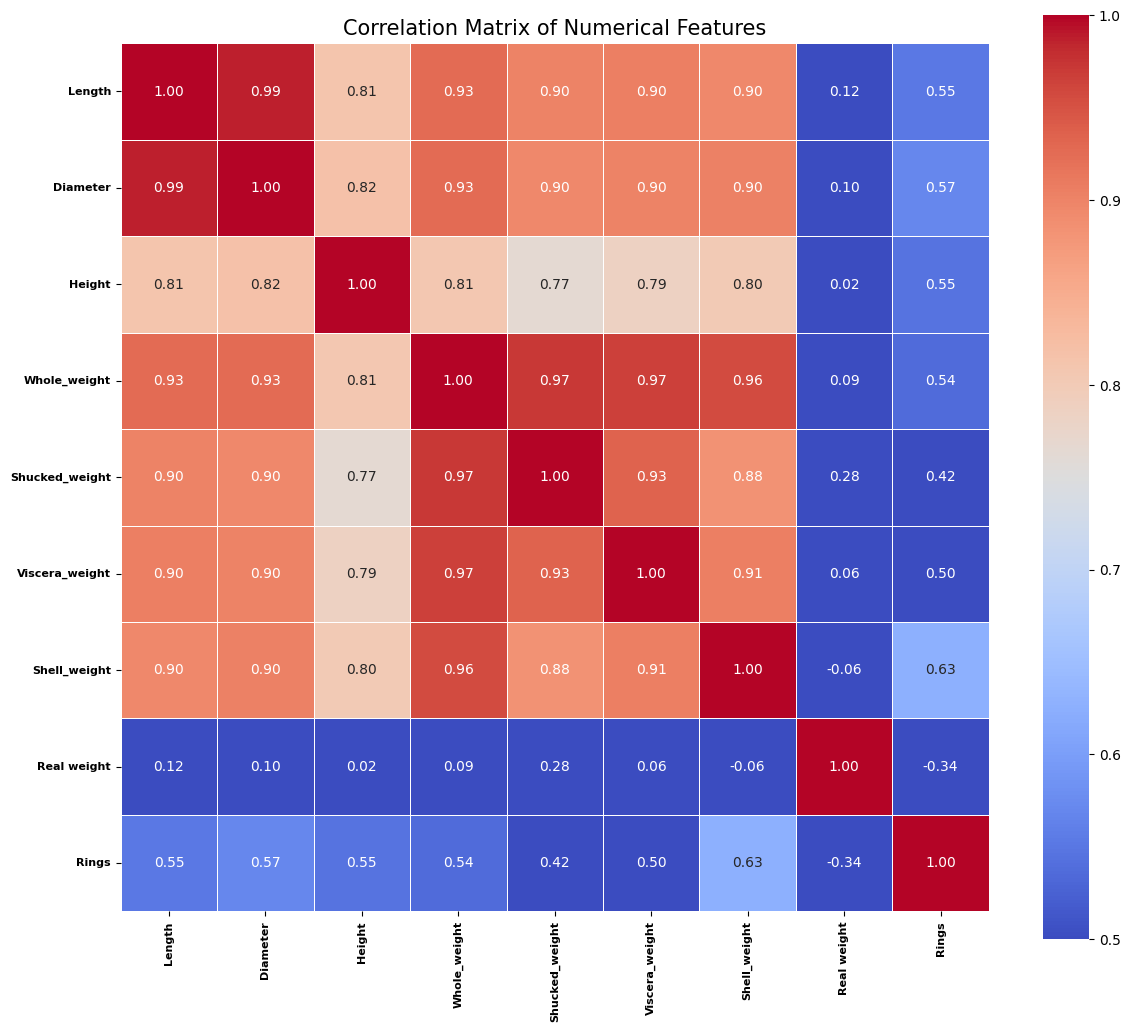

In [50]:
# 상관계수 계산
# 값 범위: -1 ~ 1 (0=상관없음)
corr_matrix = df_train[num_cols+['Rings']].corr()

# 히트맵 시각화
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, vmax=1, vmin=0.5, center=0.75,annot=True, fmt=".2f", square=True,
            linewidths=.5, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features', fontsize=15)
plt.xticks(fontsize=8,fontweight='bold')
plt.yticks(fontsize=8,fontweight='bold')
plt.show()

In [59]:
# 1-3. 스케일링
# 각기 다른 피처들의 단위를 통일 -> 평균 0, 표준편차 1로 변환

# 스케일링할 컬럼 리스트 지정
num_cols = ['Length', 'Diameter', 'Height', 'Real weight', 'Rings']

# 전처리 함수 정의 : 데이터프레임을 입력받아서 전처리한 뒤 다시 반환하는 함수
# 훈련 데이터(Train)용 함수: 스케일러를 학습하고 변환
def getFeats_train(df):
    # 예측에 사용할 피처(X)와 정답(y) 분리
    X_raw = df[num_cols]

    sex_dict = {'I': 0, 'M': 1, 'F': 2}
    y = df['Sex'].map(sex_dict).astype('int32')

    # 스케일러 생성 및 Train 데이터 기준 학습/변환
    global scaler # 테스트 데이터에서도 같은 기준을 쓰기 위해 전역 변수로 설정
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    return X_scaled, y

# 테스트 데이터(Test)용 함수: Train 기준을 빌려서 변환만 수행 (데이터 누수 방지)
def getFeats_test(df):
    X_raw = df[num_cols]

    sex_dict = {'I': 0, 'M': 1, 'F': 2}
    y = df['Sex'].map(sex_dict).astype('int32')

    # Train 데이터로 학습된 scaler를 그대로 사용하여 변환만 수행
    X_scaled = scaler.transform(X_raw)

    return X_scaled, y

# 전처리 수행 : 함수를 실행하여 Train/Test 전처리 각각 수행
X_train_full, y_train_full = getFeats_train(df_train)
X_test, y_test = getFeats_test(df_test)

In [60]:
# 1-4. 검증 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# 데이터 형태 최종 확인
print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_val Shape: {X_val.shape} | y_val Shape: {y_val.shape}")
print(f"X_test Shape: {X_test.shape} | y_test Shape: {y_test.shape}")

X_train Shape: (2672, 5) | y_train Shape: (2672,)
X_val Shape: (669, 5) | y_val Shape: (669,)
X_test Shape: (836, 5) | y_test Shape: (836,)




---



# 2. 머신러닝 : RandomForest 분류 모델 생성 + 학습
- RandomForest : 여러 개의 결정트리를 만들어서 결과를 평균하는 모델

In [63]:
# 1. 랜덤 포레스트 분류 모델 생성
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. 모델 학습 (Train)
rf_model.fit(X_train, y_train)

# 3. 검증 데이터셋(Validation)을 통한 모델 평가
y_val_pred = rf_model.predict(X_val)

# 실제 정답(y_val)과 모델의 예측값(y_val_pred)을 비교하여 정확도 계산
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"검증 데이터셋 정확도 (Validation Accuracy): {val_accuracy:.4f}")

# 4. 상세 평가지표 출력 (정밀도, 재현율 등)
# 0(I), 1(M), 2(F) 각 클래스별로 얼마나 잘 맞추었는지 상세 리포트 출력
print("\n--- 상세 분류 리포트 (Classification Report) ---")
print(classification_report(y_val, y_val_pred, target_names=['Infant', 'Male', 'Female']))

검증 데이터셋 정확도 (Validation Accuracy): 0.5007

--- 상세 분류 리포트 (Classification Report) ---
              precision    recall  f1-score   support

      Infant       0.63      0.73      0.68       200
        Male       0.44      0.45      0.44       244
      Female       0.43      0.35      0.38       225

    accuracy                           0.50       669
   macro avg       0.50      0.51      0.50       669
weighted avg       0.49      0.50      0.49       669



# 3. 딥러닝 : Dense 다중분류 모델 빌딩 및 학습

In [67]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 결과 재현을 위한 랜덤 시드 고정
tf.random.set_seed(42)
np.random.seed(42)

# 딥러닝 모델 빌딩
dl_model = Sequential([
    # 입력층 + 은닉층 1
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2), # 과적합 방지를 위해 20%의 노드 비활성화

    # 은닉층 2
    Dense(32, activation='relu'),
    Dropout(0.2),

    # 출력층 : 다중분류이므로, 활성화함수는 softmax
    Dense(3, activation='softmax')
])

# 모델 구조 확인
dl_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,563 (10.01 KB)

 Trainable params: 2,563 (10.01 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# 모델 컴파일 (손실함수 및 옵티마이저 설정)
# 정답(y)이 원-핫 인코딩이 아닌 0, 1, 2 정수 형태이므로 sparse_categorical_crossentropy 사용
dl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [70]:
# 콜백 함수 정의 (EarlyStopping, ReduceLROnPlateau)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True, # 종료 후 가장 좋은 가중치로 복원
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=5,
    factor=0.2,
    min_lr=1e-6,
    verbose=1
)

In [71]:
# 모델 학습 수행
history = dl_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5026 - loss: 0.9475 - val_accuracy: 0.5172 - val_loss: 0.9102 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5232 - loss: 0.8996 - val_accuracy: 0.5217 - val_loss: 0.8996 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5262 - loss: 0.8891 - val_accuracy: 0.5217 - val_loss: 0.9004 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5371 - loss: 0.8833 - val_accuracy: 0.5247 - val_loss: 0.8952 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5385 - loss: 0.8828 - val_accuracy: 0.5232 - val_loss: 0.8942 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5378 - loss: 0.8797 - val_accuracy: 0.5262 - val_loss: 0.8926 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5371 - loss: 0.8763 - val_acc

In [72]:
# 검증 데이터셋 최종 평가
val_loss, val_acc = dl_model.evaluate(X_val, y_val, verbose=0)
print("\n" + "="*50)
print(f"딥러닝 모델 검증 데이터셋 정확도: {val_acc:.4f}")
print("="*50)


딥러닝 모델 검증 데이터셋 정확도: 0.5232


In [74]:
# 상세 분류 리포트
y_val_prob = dl_model.predict(X_val)
y_val_pred_dl = np.argmax(y_val_prob, axis=-1)

print("\n--- 딥러닝 모델 상세 분류 리포트 (Classification Report) ---")
print(classification_report(y_val, y_val_pred_dl, target_names=['Infant', 'Male', 'Female']))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

--- 딥러닝 모델 상세 분류 리포트 (Classification Report) ---
              precision    recall  f1-score   support

      Infant       0.61      0.79      0.69       200
        Male       0.46      0.56      0.50       244
      Female       0.50      0.24      0.33       225

    accuracy                           0.52       669
   macro avg       0.52      0.53      0.51       669
weighted avg       0.52      0.52      0.50       669

